In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt


In [3]:
from pandas import DataFrame

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))
all_visits = {}

for file in csv_files:
    df = pd.read_csv(file, sep=";")

    filename = file.stem
    visit = filename.split("_")[1]

    df["visit"] = visit

    all_visits[visit] = df

C:\Users\veron\AppData\Local\Temp\ipykernel_17480\252853293.py:8: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,1204

In [4]:
top_meds_per_visit = {}

for visit, df in all_visits.items():
    MED_COLUMN = f"acute_name_a1_K{visit[1:]}"
    if MED_COLUMN not in df.columns:
        print(f"{visit}: Spalte {MED_COLUMN} nicht gefunden")
        continue

    meds = (
        df[MED_COLUMN]
        .dropna()
        .astype(str)
        .str.strip()
    )

    meds = meds[(meds != "") & (meds != "0")]

    top_meds = meds.value_counts().head(20)

    top_meds_per_visit[visit] = top_meds

Vlast: Spalte acute_name_a1_Klast nicht gefunden


In [5]:
dfs = []
PATIENT_ID_COLUMN = "id_patient"

for visit, df in all_visits.items():

    med_col = f"acute_name_a1_K{visit[1:]}"

    if med_col not in df.columns:
        print(f"{visit}: Spalte {med_col} fehlt")
        continue

    temp = df[[PATIENT_ID_COLUMN, med_col]].copy()
    temp["visit"] = visit

    temp = temp.rename(columns={med_col: "medication"})

    dfs.append(temp)

combined_df = pd.concat(dfs, ignore_index=True)

print("\nGesamte Zeilen:", len(combined_df))

Vlast: Spalte acute_name_a1_Klast fehlt

Gesamte Zeilen: 17866


In [6]:
PATIENT_ID_COLUMN = "id_patient"


relevant = combined_df.dropna(subset=[PATIENT_ID_COLUMN])

relevant["medication"] = (
    relevant["medication"]
    .fillna("")
    .astype(str)
    .str.strip()
)

relevant = relevant[(relevant["medication"] != "") & (relevant["medication"] != "0")]
visit_order = sorted(
    [v for v in all_visits.keys() if v[1:].isdigit()],
    key=lambda v: int(v[1:])
)

print("\nVisit Reihenfolge:")
print(visit_order)


Visit Reihenfolge:
['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23']


In [7]:
changes = []

for patient_id, patient_df in relevant.groupby(PATIENT_ID_COLUMN):

    patient_visits = {}

    for visit in visit_order:

        visit_df = patient_df[patient_df["visit"] == visit]

        meds = set(
            visit_df["medication"]
            .dropna()
            .astype(str)
            .str.strip()
        )

        meds = {m for m in meds if m != "" and m != "0"}

        patient_visits[visit] = meds

    for i in range(len(visit_order) - 1):

        current_visit = visit_order[i]
        next_visit = visit_order[i + 1]

        current_meds = patient_visits.get(current_visit, set())
        next_meds = patient_visits.get(next_visit, set())

        added = next_meds - current_meds
        removed = current_meds - next_meds

        if added or removed:
            changes.append({
                "id_patient": patient_id,
                "from_visit": current_visit,
                "to_visit": next_visit,
                "added_meds": list(added),
                "removed_meds": list(removed),
                "n_added": len(added),
                "n_removed": len(removed)
            })

changes_df = pd.DataFrame(changes)

print("\n" + "=" * 50)
print("MEDIKAMENTEN-ÄNDERUNGEN")
print("=" * 50)

display(changes_df.head(20))


MEDIKAMENTEN-ÄNDERUNGEN


,id_patient,from_visit,to_visit,added_meds,removed_meds,n_added,n_removed
0,10007520,V1,V2,[],[Rizatriptan],0,1
1,10070992,V1,V2,[Metamizol],[Ibuprofen],1,1
2,10070992,V3,V4,[],[Metamizol],0,1
3,10072456,V1,V2,[],[Ibuprofen],0,1
4,10076150,V1,V2,[],[Ibuprofen],0,1
5,10076484,V2,V3,[Metamizol],[Ibuprofen],1,1
6,10076484,V3,V4,[Ibuprofen],[Metamizol],1,1
7,10076484,V5,V6,[],[Ibuprofen],0,1
8,10098623,V1,V2,[],[Rizatriptan],0,1
9,10098623,V2,V3,[Rizatriptan],[],1,0


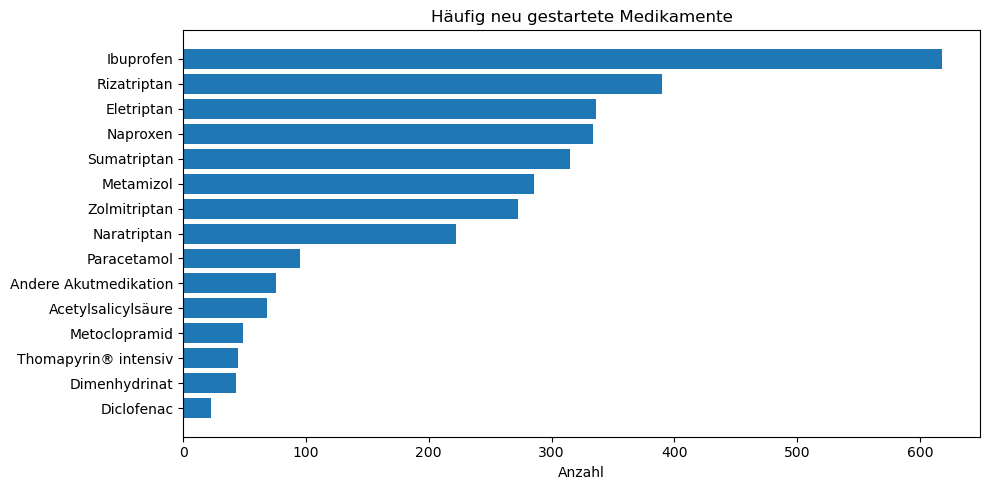

In [8]:
from collections import Counter

added_counter = Counter()

for meds in changes_df["added_meds"]:
    added_counter.update(meds)

top_added = pd.DataFrame(added_counter.most_common(15), columns=["medication", "count"])

plt.figure(figsize=(10,5))
plt.barh(top_added["medication"][::-1], top_added["count"][::-1])
plt.title("Häufig neu gestartete Medikamente")
plt.xlabel("Anzahl")
plt.tight_layout()
plt.show()

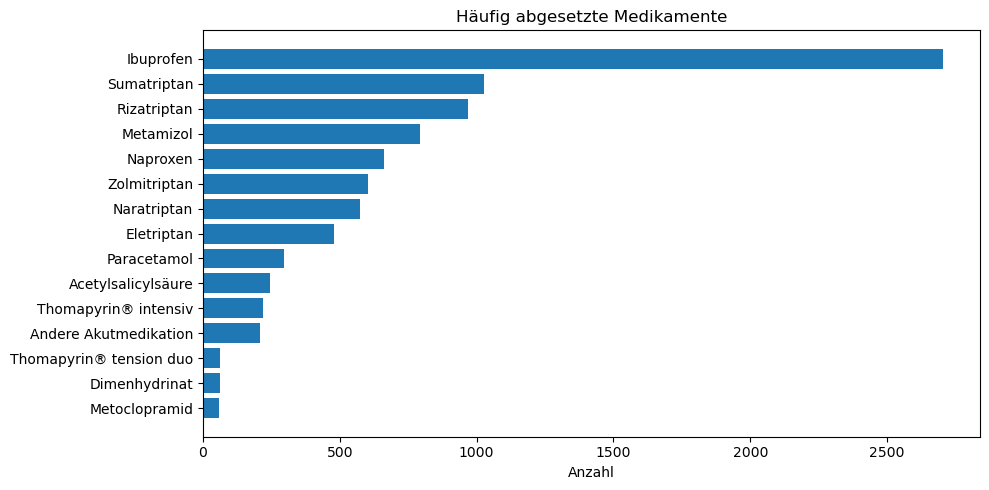

In [9]:
removed_counter = Counter()

for meds in changes_df["removed_meds"]:
    removed_counter.update(meds)

top_removed = pd.DataFrame(removed_counter.most_common(15), columns=["medication", "count"])

plt.figure(figsize=(10,5))
plt.barh(top_removed["medication"][::-1], top_removed["count"][::-1])
plt.title("Häufig abgesetzte Medikamente")
plt.xlabel("Anzahl")
plt.tight_layout()
plt.show()

In [10]:
TARGETS = [
    "dass_depression_K1",
    "dass_fear_K1",
    "dass_stress_K1",
    "midas_result_K1",
    "vr12_msc_K1",
    "vr12_psc_K1",
    "gvas_result_K1",
    "pgic_result_K1",
    "chiq_result_K1"
]

dfs = []

for visit in visit_order:    

    df = all_visits[visit]

    suffix = visit[1:]

    med_col = f"acute_name_a1_K{suffix}"

    if med_col not in df.columns:
        print(f"{visit}: {med_col} fehlt")
        continue

    cols = [PATIENT_ID_COLUMN, med_col]

    visit_targets = []

    for target in TARGETS:

        target_col = target.replace("_K1", f"_K{suffix}")

        if target_col in df.columns:
            visit_targets.append(target_col)

    cols.extend(visit_targets)

    temp = df[cols].copy()

    temp["visit"] = visit

    temp.rename(columns={med_col: "medication"}, inplace=True)

    rename_dict = {}

    for target in TARGETS:
        target_col = target.replace("_K1", f"_K{suffix}")

        if target_col in temp.columns:
            rename_dict[target_col] = target.replace("_K1", "")

    temp.rename(columns=rename_dict, inplace=True)

    dfs.append(temp)

analysis_df = pd.concat(dfs, ignore_index=True)

print(analysis_df.shape)
display(analysis_df.head())

(17866, 12)


,id_patient,medication,dass_depression,dass_fear,dass_stress,midas_result,vr12_msc,vr12_psc,gvas_result,pgic_result,chiq_result,visit
0,10007520,Rizatriptan,1,4,3,32,"46,03172437753470","28,913794763421",42,NaN,NaN,V1
1,10022137,0,6,4,9,25,"35,11080638971150","34,527583129731",32,NaN,NaN,V1
2,10070992,Ibuprofen,1,8,4,87,"54,60844012442910","41,659009762141",40,NaN,NaN,V1
3,10072456,Ibuprofen,1,0,1,24,"54,12235362455200","42,046472381851",69,NaN,NaN,V1
4,10076150,Ibuprofen,0,6,7,19,"49,93507878854840","53,759163923581",90,NaN,NaN,V1


In [11]:
cols = [
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "midas_result",
    "vr12_msc",
    "vr12_psc",
    "gvas_result",
    "pgic_result",
    "chiq_result"
]

for c in cols:
    analysis_df[c] = pd.to_numeric(analysis_df[c], errors="coerce")

In [12]:
analysis_df.groupby("medication")[cols].mean().sort_values("dass_depression")

,dass_depression,dass_fear,dass_stress,midas_result,vr12_msc,vr12_psc,gvas_result,pgic_result,chiq_result
medication,,,,,,,,,
Voltaren® plus,0.000000,0.000000,0.000000,4.000000,NaN,NaN,88.000000,NaN,NaN
Suvexx® (Sumatriptan/Naproxen 85mg/500mg),0.000000,1.500000,1.500000,39.500000,NaN,NaN,80.000000,3.000000,NaN
Doppel Spalt®,0.000000,0.000000,0.000000,0.000000,NaN,NaN,89.000000,4.000000,NaN
Tramabian® 75 mg/650 mg,0.500000,1.000000,1.500000,0.500000,NaN,NaN,63.000000,4.000000,NaN
Ergotamintartrat,2.000000,2.000000,6.000000,15.000000,NaN,NaN,58.000000,NaN,NaN
Talvosilen® forte,2.000000,1.000000,4.000000,31.000000,NaN,NaN,26.000000,NaN,NaN
Paracetamol comp STADA,2.250000,3.250000,7.250000,33.750000,NaN,NaN,60.500000,3.000000,NaN
Lidocain nasal,2.500000,5.500000,2.500000,25.000000,NaN,NaN,43.500000,NaN,NaN
"Zaldiar® 37,5 mg/325 mg",3.000000,2.000000,5.000000,140.000000,NaN,NaN,24.000000,NaN,NaN


In [13]:
cols = [
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "midas_result",
    "gvas_result",
    "pgic_result",
    "chiq_result"
]

analysis_df[cols] = analysis_df[cols].apply(pd.to_numeric, errors="coerce")

In [14]:
agg = analysis_df.groupby("medication").agg(
    {c: "mean" for c in cols} | {"id_patient": "count"}
).rename(columns={"id_patient": "n_patients"})

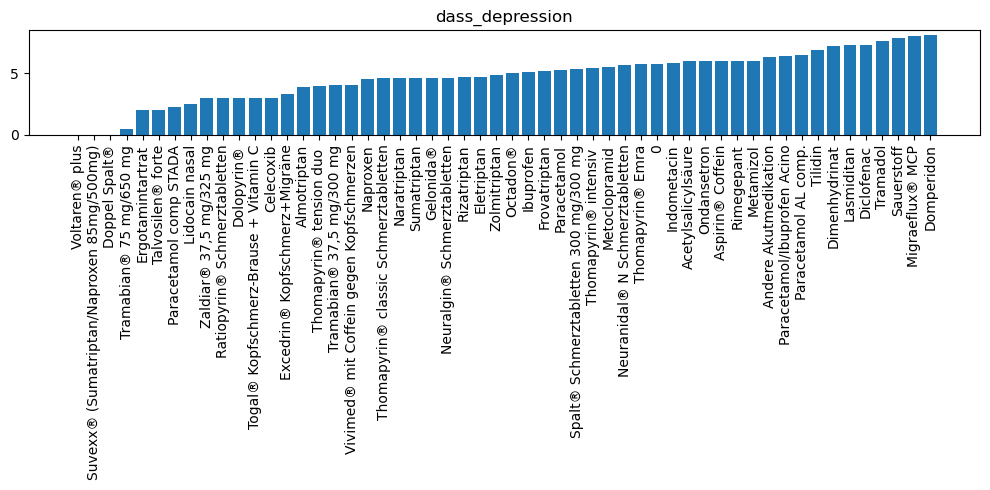

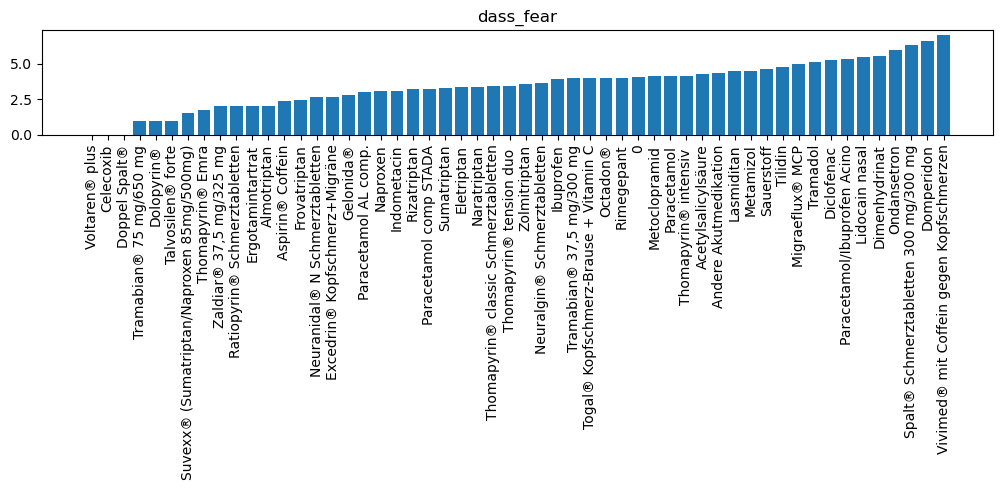

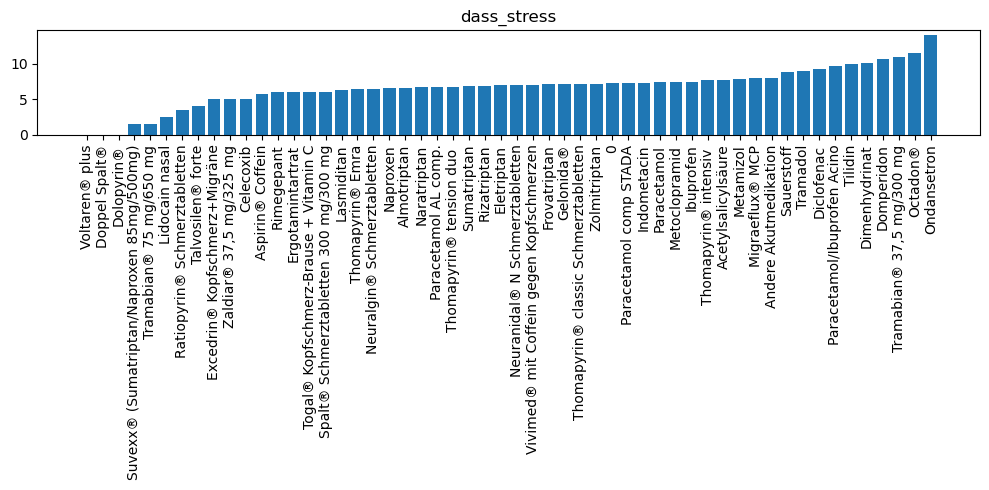

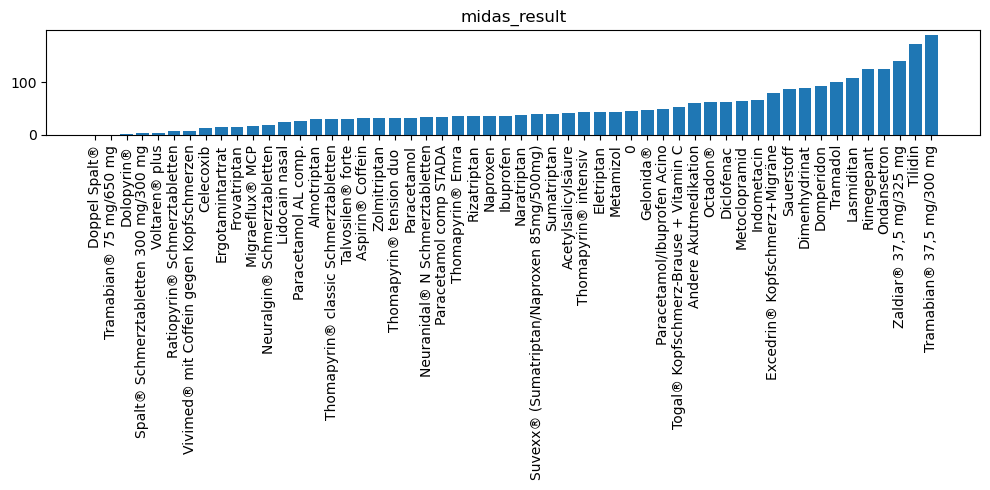

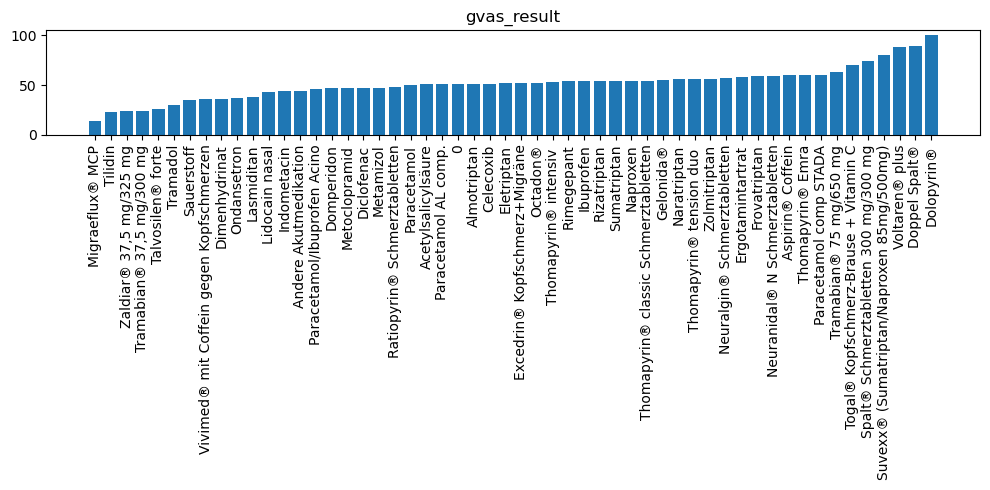

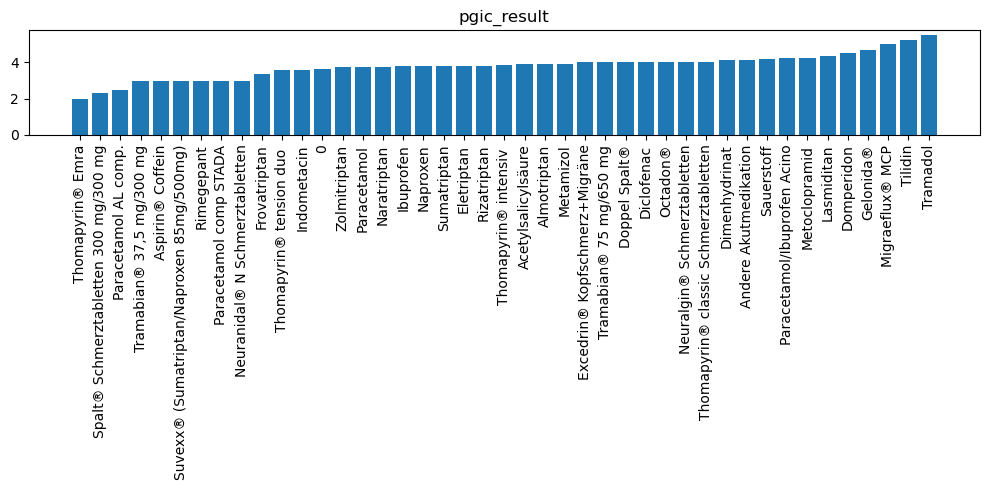

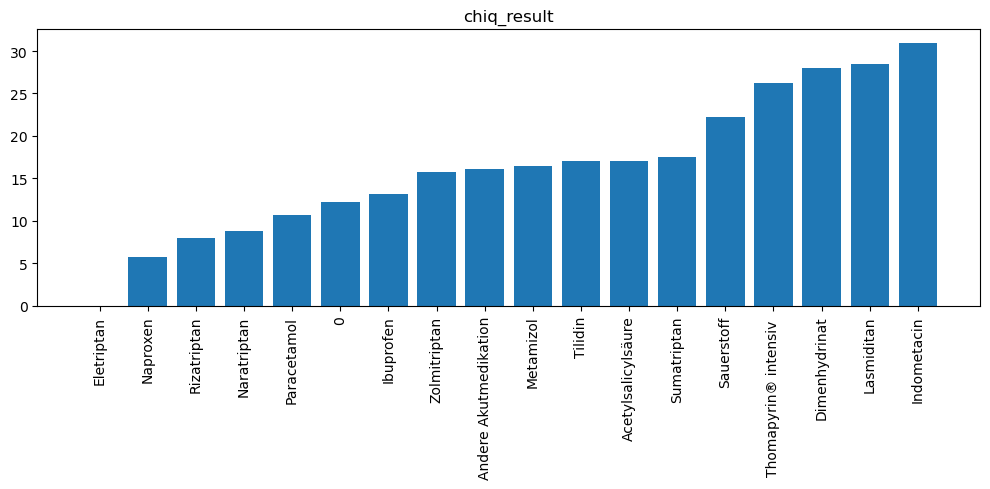

In [15]:
import matplotlib.pyplot as plt

for col in cols:

    tmp = analysis_df.groupby("medication")[col].mean()

    tmp = tmp.dropna()

    if tmp.empty:
        print(f"Skipping {col} (no data)")
        continue

    tmp = tmp.sort_values()

    plt.figure(figsize=(10,5))
    plt.bar(tmp.index, tmp.values)

    plt.xticks(rotation=90)
    plt.title(col)

    plt.tight_layout()
    plt.show()
    

In [16]:
cols = [
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "midas_result",
    "gvas_result",
    "pgic_result",
    "chiq_result"
]


analysis_df[cols] = analysis_df[cols].apply(pd.to_numeric, errors="coerce")

In [17]:
analysis_df = analysis_df.dropna(subset=["medication", "id_patient"])

min_n = 10

valid_meds = (
    analysis_df.groupby("medication")["id_patient"]
    .nunique()
)

valid_meds = valid_meds[valid_meds >= min_n].index

df = analysis_df[analysis_df["medication"].isin(valid_meds)].copy()

In [18]:
def get_outliers(df, cols, iqr_factor=1.5):
    outlier_rows = pd.DataFrame()

    for c in cols:
        q1 = df[c].quantile(0.25)
        q3 = df[c].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - iqr_factor * iqr
        upper = q3 + iqr_factor * iqr

        mask = (df[c] < lower) | (df[c] > upper)

        tmp = df[mask].copy()
        tmp["outlier_variable"] = c
        tmp["lower_bound"] = lower
        tmp["upper_bound"] = upper

        outlier_rows = pd.concat([outlier_rows, tmp], ignore_index=True)

    return outlier_rows

outliers_df = get_outliers(df, cols)


In [19]:
outliers_df.sort_values("medication").head(50)

,id_patient,medication,dass_depression,dass_fear,dass_stress,midas_result,vr12_msc,vr12_psc,gvas_result,pgic_result,chiq_result,visit,outlier_variable,lower_bound,upper_bound
1891,52472759,0,11,0,14,174,NaN,NaN,32,3.0,NaN,V3,midas_result,-52.5,111.5
2003,43986852,0,4,6,6,184,NaN,NaN,0,7.0,NaN,V4,midas_result,-52.5,111.5
379,11605442,0,15,17,17,60,NaN,NaN,21,NaN,NaN,V1,dass_fear,-6.5,13.5
1159,39930771,0,6,2,4,252,NaN,NaN,57,NaN,NaN,V1,midas_result,-52.5,111.5
1542,88048165,0,19,17,17,194,NaN,NaN,15,NaN,NaN,V1,midas_result,-52.5,111.5
121,70964597,0,19,15,19,34,NaN,NaN,33,NaN,NaN,V1,dass_depression,-9.5,18.5
478,45757620,0,18,18,18,11,NaN,NaN,9,NaN,NaN,V1,dass_fear,-6.5,13.5
1688,39024049,0,13,8,14,210,NaN,NaN,50,3.0,NaN,V2,midas_result,-52.5,111.5
2013,48939671,0,19,15,11,115,NaN,NaN,16,6.0,NaN,V4,midas_result,-52.5,111.5
1162,40273212,0,1,1,2,195,NaN,NaN,17,NaN,NaN,V1,midas_result,-52.5,111.5


In [20]:
outliers_df["outlier_variable"].value_counts()

outlier_variable
midas_result       1488
dass_fear           572
dass_depression     375
Name: count, dtype: int64

In [21]:
outliers_df["medication"].value_counts()

medication
Ibuprofen                               570
Metamizol                               251
Sumatriptan                             245
Rizatriptan                             234
0                                       174
Naproxen                                163
Eletriptan                              138
Naratriptan                             129
Zolmitriptan                            104
Andere Akutmedikation                    89
Thomapyrin® intensiv                     55
Acetylsalicylsäure                       54
Paracetamol                              49
Dimenhydrinat                            35
Diclofenac                               30
Tilidin                                  19
Sauerstoff                               16
Domperidon                               16
Metoclopramid                            15
Lasmiditan                               14
Thomapyrin® classic Schmerztabletten     11
Thomapyrin® tension duo                   8
Almotriptan          

In [22]:
agg_mean = df.groupby("medication")[cols].mean()
agg_median = df.groupby("medication")[cols].median()
agg_n = df.groupby("medication")["id_patient"].nunique()

In [23]:
agg = agg_mean.join(agg_median, lsuffix="_mean", rsuffix="_median")
agg["id_patient"] = agg_n

In [24]:
agg = agg.reset_index()

In [25]:
def plot_outcome(df, outcome):

    median_col = f"{outcome}_median"

    plot_df = df[["medication", median_col, "id_patient"]].copy()
    plot_df = plot_df.sort_values(median_col)

    plt.figure(figsize=(12, 5))

    plt.bar(plot_df["medication"], plot_df[median_col])

    plt.xticks(rotation=90)
    plt.ylabel(outcome)
    plt.title(f"{outcome} nach Medikament")

    for i, (val, n) in enumerate(zip(plot_df[median_col], plot_df["id_patient"])):
        plt.text(i, val, f"n={n}", ha="center", va="bottom", fontsize=8)

    plt.tight_layout()
    plt.show()

In [26]:
print(agg.columns)

Index(['medication', 'dass_depression_mean', 'dass_fear_mean',
       'dass_stress_mean', 'midas_result_mean', 'gvas_result_mean',
       'pgic_result_mean', 'chiq_result_mean', 'dass_depression_median',
       'dass_fear_median', 'dass_stress_median', 'midas_result_median',
       'gvas_result_median', 'pgic_result_median', 'chiq_result_median',
       'id_patient'],
      dtype='object')


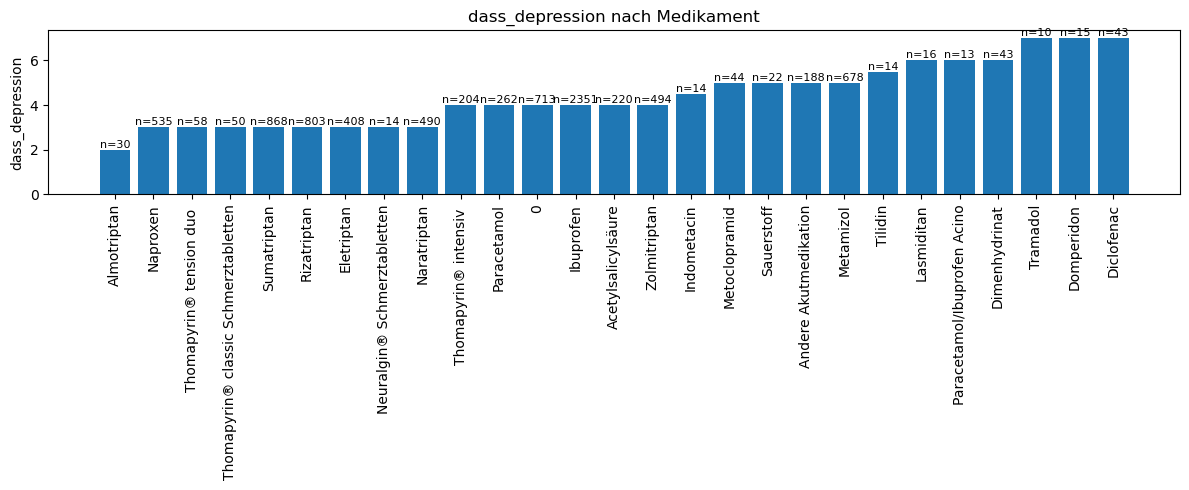

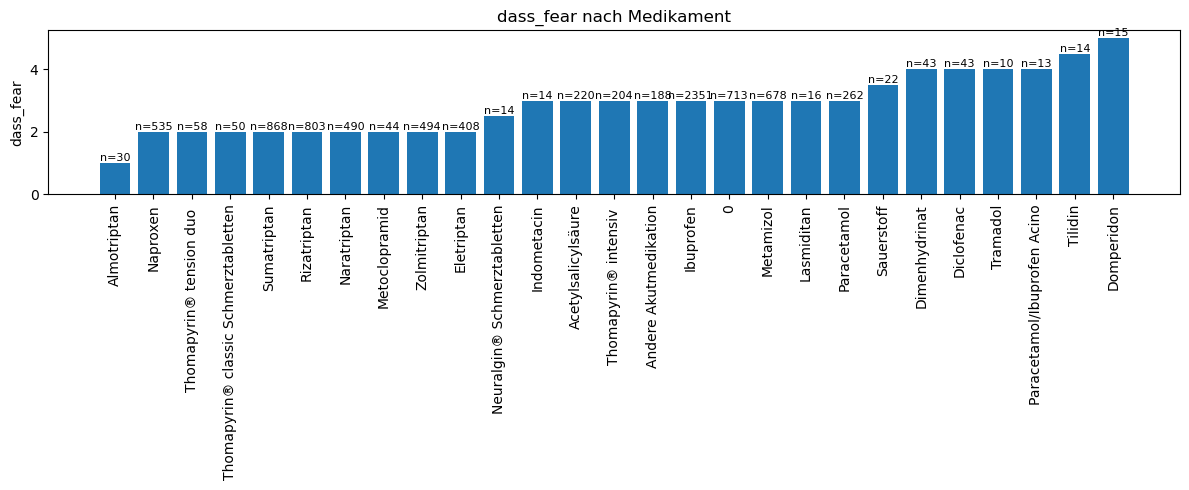

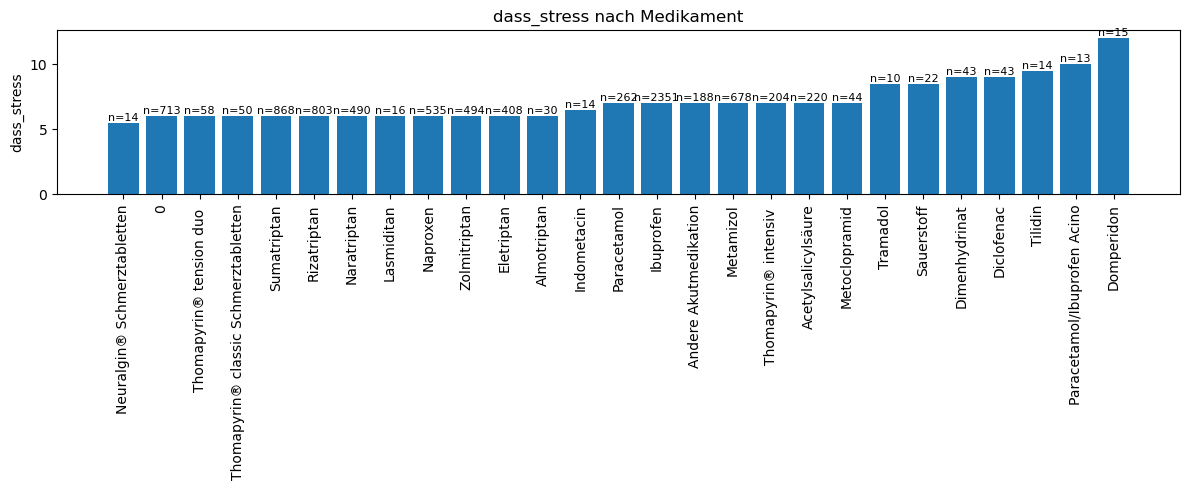

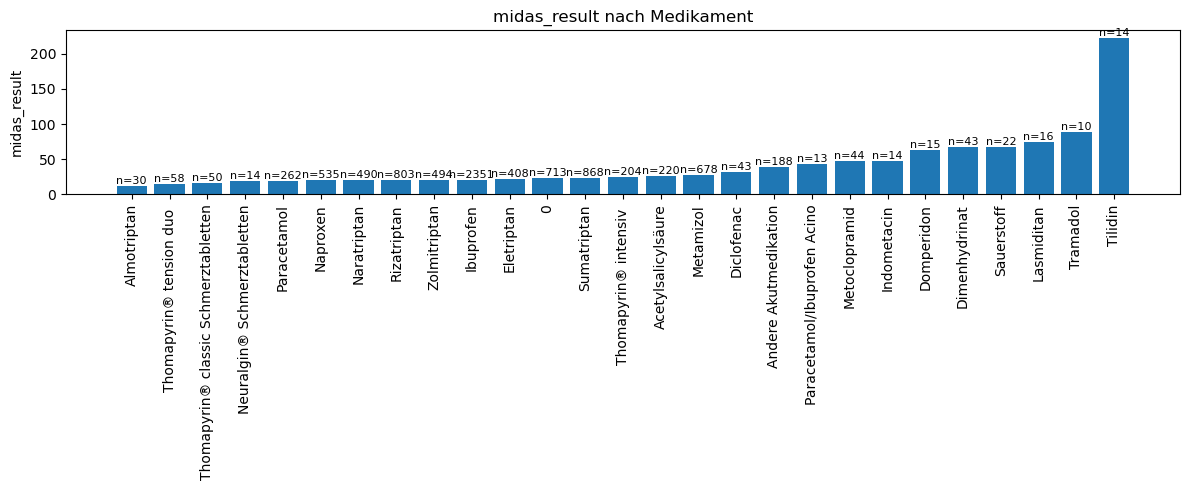

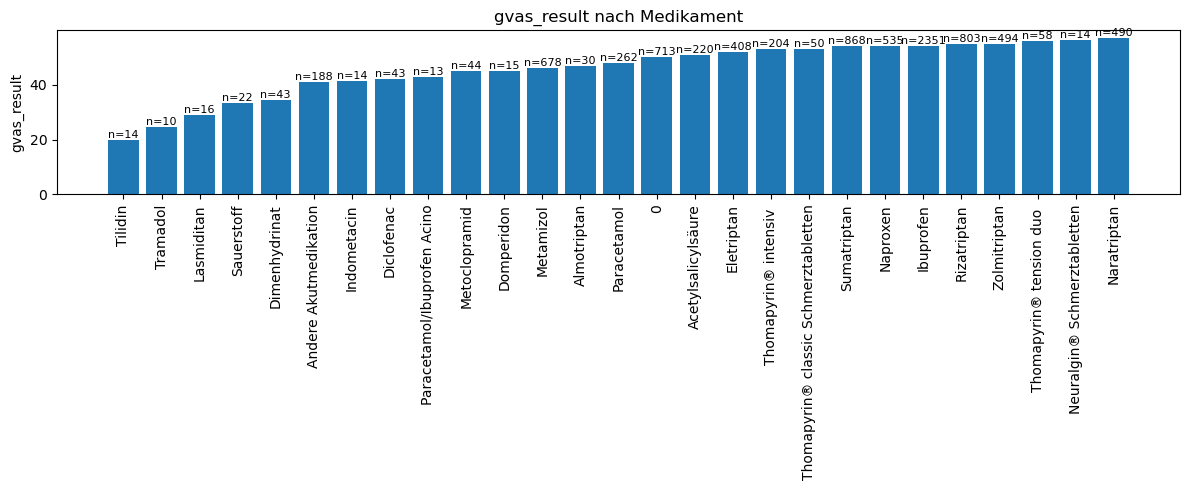

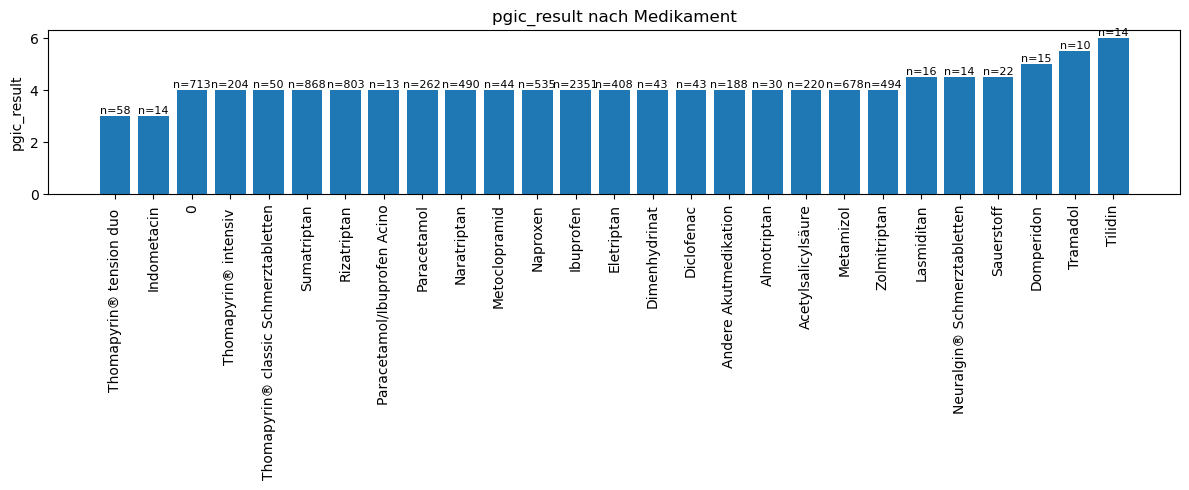

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


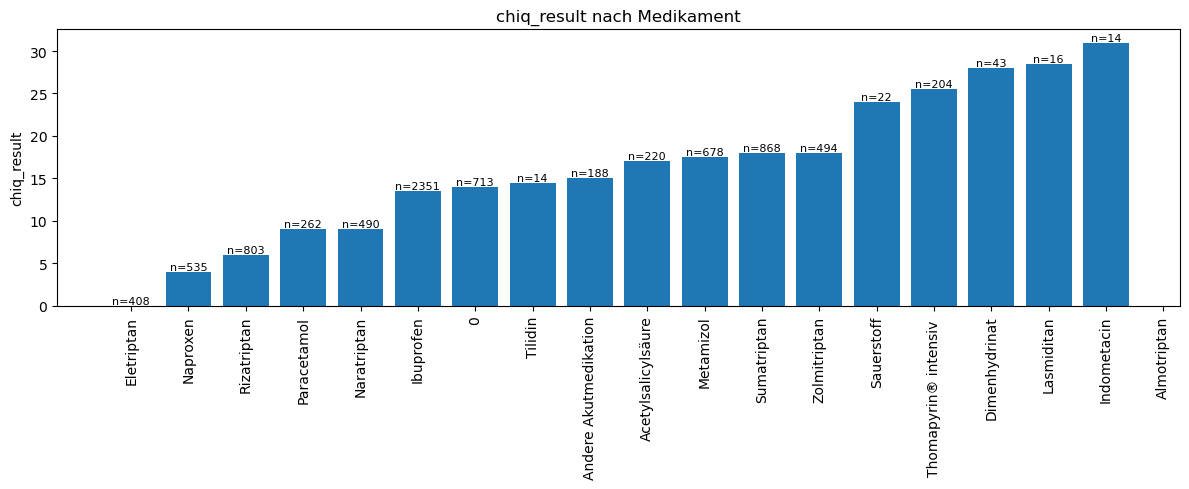

In [27]:
for c in cols:
    plot_outcome(agg, c)

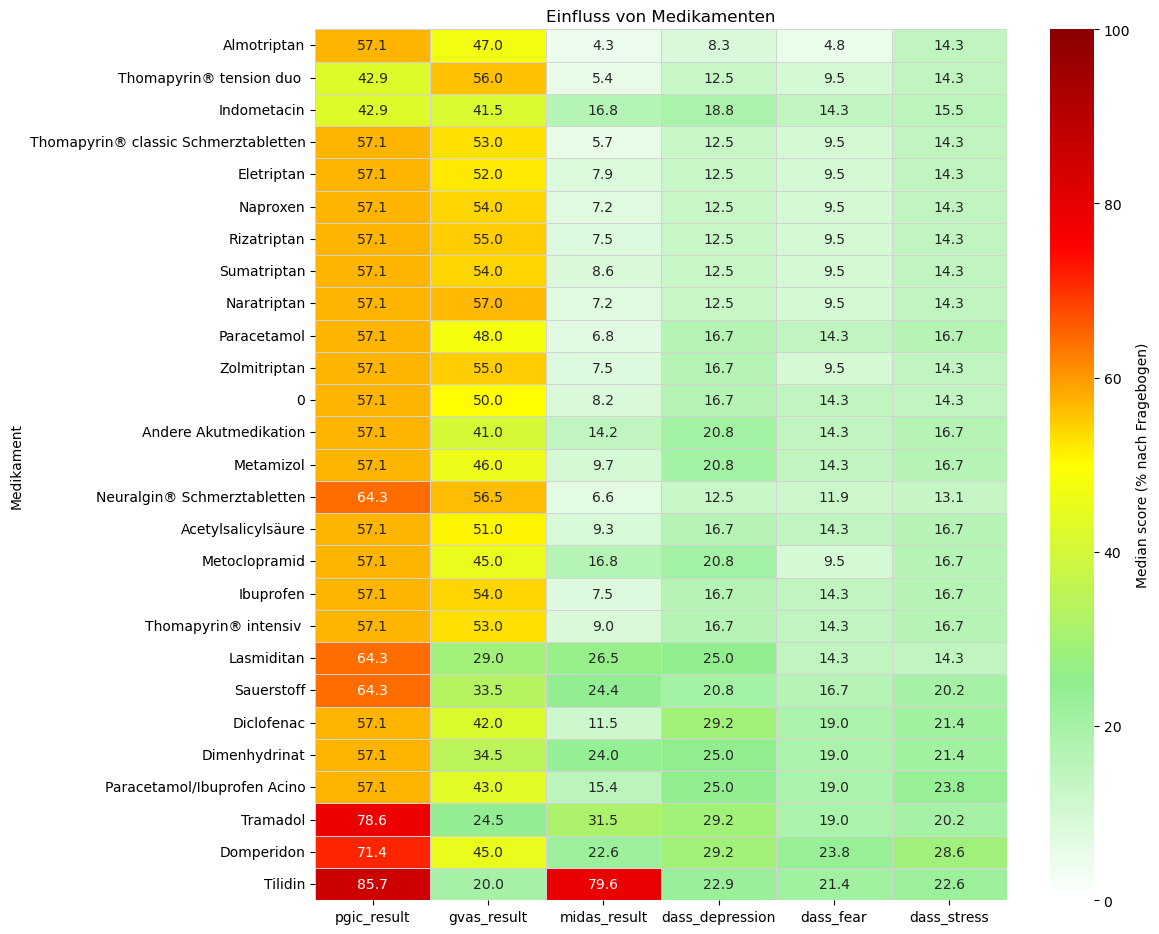

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Normalize each questionnaire to percentage of maximum possible score
outcome_max_values = {
    "pgic_result": 7,
    "gvas_result": 100,
    "midas_result": 279,
    "dass_depression": 24,
    "dass_fear": 21,
    "dass_stress": 42
}

# Create percentage-based median columns
for outcome, max_value in outcome_max_values.items():
    agg[f"{outcome}_median_pct"] = (
        agg[f"{outcome}_median"] / max_value * 100
    )

# Prepare data
plot_df = agg[
    ["medication"] +
    [f"{outcome}_median_pct" for outcome in outcome_max_values]
].copy()

# Sort medications by mean of available values
plot_df["mean_percentage"] = plot_df[
    [f"{outcome}_median_pct" for outcome in outcome_max_values]
].mean(axis=1, skipna=True)

plot_df = (
    plot_df
    .sort_values("mean_percentage")
    .drop(columns="mean_percentage")
    .set_index("medication")
)

# Keep your existing labels
plot_df.columns = [
    "pgic_result",
    "gvas_result",
    "midas_result",
    "dass_depression",
    "dass_fear",
    "dass_stress"
]

# Custom colormap:
# 0% = white
# increasing values = increasingly intense red
white_to_red = LinearSegmentedColormap.from_list(
    "white_to_red",
    ["white", "lightgreen", "yellow", "red", "darkred"]
)

# Heatmap
plt.figure(figsize=(12, max(8, len(plot_df) * 0.35)))

sns.heatmap(
    plot_df,
    annot=True,
    fmt=".1f",
    cmap=white_to_red,
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="lightgray",
    cbar_kws={"label": "Median score (% nach Fragebogen)"}
)


plt.ylabel("Medikament")
plt.title("Einfluss von Medikamenten")

plt.tight_layout()
plt.show()

In [41]:
from scipy.stats import kruskal

# Beispiel: PGIC-Werte zwischen Medikamentengruppen vergleichen
groups = [
    group["pgic_result"].dropna()
    for medication, group in df.groupby("medication")
]

stat, p_value = kruskal(*groups)

print("Kruskal-Wallis-Test")
print("Teststatistik:", stat)
print("p-Wert:", p_value)

Kruskal-Wallis-Test
Teststatistik: 90.89129689518008
p-Wert: 3.995992619540774e-09


In [42]:
import statsmodels.formula.api as smf

model = smf.ols(
    "pgic_result ~ C(medication)",
    data=analysis_df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            pgic_result   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     2.639
Date:                Sun, 19 Jul 2026   Prob (F-statistic):           4.54e-08
Time:                        20:20:34   Log-Likelihood:                -19143.
No. Observations:               11235   AIC:                         3.837e+04
Df Residuals:                   11192   BIC:                         3.869e+04
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

In [129]:
analysis_df["diclofenac"] = (
    analysis_df["medication"]
    .astype(str)
    .str.lower()
    .str.contains("diclofenac", na=False)
).astype(int)

analysis_df["naratriptan"] = (
    analysis_df["medication"]
    .astype(str)
    .str.lower()
    .str.contains("naratriptan", na=False)
).astype(int)

analysis_df["almotriptan "] = (
    analysis_df["medication"]
    .astype(str)
    .str.lower()
    .str.contains("almotriptan ", na=False)
).astype(int)

In [120]:
analysis_df["dass_depression"] = pd.to_numeric(
    analysis_df["dass_depression"], errors="coerce"
)

analysis_df.groupby("diclofenac")["dass_depression"].agg(
    ["mean", "median", "count"]
)

,mean,median,count
diclofenac,,,
0,5.053434,3.0,17779
1,7.310345,7.0,87


In [ ]:
patient_level = analysis_df.groupby("id_patient").agg({
    "diclofenac": "max",
    "dass_depression": "mean",
    "age_reg": "first",
    "gender": "first"
}).dropna()

In [ ]:
patient_level.groupby("diclofenac")["dass_depression"].agg(
    ["mean", "std", "count"]
)

,mean,std,count
diclofenac,,,
0,5.395936,4.879729,6588
1,7.661879,5.443083,43


In [ ]:
patient_level[["diclofenac", "dass_depression"]].corr()

,diclofenac,dass_depression
diclofenac,1.000000,0.037223
dass_depression,0.037223,1.000000


In [ ]:
import statsmodels.api as sm

X = patient_level[["diclofenac"]]
X = sm.add_constant(X)

y = patient_level["dass_depression"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        dass_depression   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     9.198
Date:                Mon, 08 Jun 2026   Prob (F-statistic):            0.00243
Time:                        09:18:59   Log-Likelihood:                -19924.
No. Observations:                6631   AIC:                         3.985e+04
Df Residuals:                    6629   BIC:                         3.987e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3959      0.060     89.683      0.0

In [ ]:
clinical_cols = [
    "id_patient",
    "visit",
    "intensity_K1",
    "headache_days_per_month_K1",
    "headache_days_severe_per_month_K1"
]

clinical = pd.concat([
    df[[c for c in clinical_cols if c in df.columns]]
    for df in all_visits.values()
], ignore_index=True)

In [ ]:
analysis_df = analysis_df.merge(
    baseline,
    on="id_patient",
    how="left"
)

In [ ]:
analysis_df = analysis_df.merge(
    clinical,
    on=["id_patient", "visit"],
    how="left"
)

In [130]:
patient_level = analysis_df.groupby("id_patient").agg({
    "naratriptan": "max",
    "midas_result": "mean"
}).dropna()

In [131]:

X = patient_level[["naratriptan"]]
X = sm.add_constant(X)

y = patient_level["midas_result"]

model = sm.OLS(y, X, missing="drop").fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           midas_result   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     7.062
Date:                Mon, 08 Jun 2026   Prob (F-statistic):            0.00789
Time:                        11:39:36   Log-Likelihood:                -35020.
No. Observations:                6631   AIC:                         7.004e+04
Df Residuals:                    6629   BIC:                         7.006e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          44.4298      0.607     73.175      